# Klipper Thermistor Calibration

We found that each heater thermistor has a slightly different temperature-resistence curve. To get consistent extrusion force, we have to calibrate the temperature-resistence curves of all the  thermistors. In this notebook, we develop some tools for calibration.

## 0 Packages

In [38]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams["font.family"] = "STIXGeneral"
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams["xtick.direction"] = "in"
matplotlib.rcParams["ytick.direction"] = "in"
plt.rcParams['xtick.major.size'] = 2  # Length of major ticks
plt.rcParams['ytick.major.size'] = 2  # Length of major ticks
plt.rcParams['xtick.minor.size'] = 1  # Length of minor ticks
plt.rcParams['ytick.minor.size'] = 1  # Length of minor ticks

## 1 Solve resistence from thermistor temperature

In [8]:
def steinhart(R, A, B, C):
    """
    Calculate the temperature in Celsius from the resistance of a thermistor using the Steinhart-Hart equation.

    Parameters:
    R (float): Resistance of the thermistor in ohms.
    A (float): Steinhart-Hart coefficient A.
    B (float): Steinhart-Hart coefficient B.
    C (float): Steinhart-Hart coefficient C.

    Returns:
    float: Temperature in Celsius.
    """

    # Calculate the natural logarithm of the resistance
    lnR = np.log(R)

    # Apply the Steinhart-Hart equation
    inv_T = A + B * lnR + C * (lnR ** 3)

    # Convert from Kelvin to Celsius
    T_Celsius = (1 / inv_T) - 273.15

    return T_Celsius

In [10]:
def func(R, A, B, C, T):
    """
    Function to be used with fsolve to find the resistance corresponding to a given temperature.

    Parameters:
    R (float): Resistance of the thermistor in ohms.
    A (float): Steinhart-Hart coefficient A.
    B (float): Steinhart-Hart coefficient B.
    C (float): Steinhart-Hart coefficient C.
    T (float): Temperature in Celsius.

    Returns:
    float: The difference between the calculated temperature and the target temperature.
    """
    return steinhart(R, A, B, C) - T

In [61]:
a = 7.96e-4
b = 2.14e-4
c = 6.58e-8
root = fsolve(func, args=(a, b, c, 343.5), x0=100)
root

array([46.56402369])

## 2 Fit temperature-resistence curve with measured data

In [24]:
from scipy.optimize import curve_fit
import pandas as pd

In [47]:
sh = pd.read_csv("~/Documents/sh.csv")

In [48]:
sh

,d1,d2,d3,R
0,195,200.0,199.5,440.17
1,212,221.0,220.0,298.59
2,244,252.0,251.5,175.93
3,278,286.0,287.0,109.54
4,317,325.0,327.0,71.50
5,391,NaN,NaN,43.07


In [27]:
popt, pcov = curve_fit(steinhart, sh["R"], sh["d1"], p0=[a, b, c])

In [ ]:
popt

array([ 1.93076491e-04,  3.82841636e-04, -1.71130693e-06])

d1: [array([310.24240981]), array([119.64693759]), array([71.94779604])]


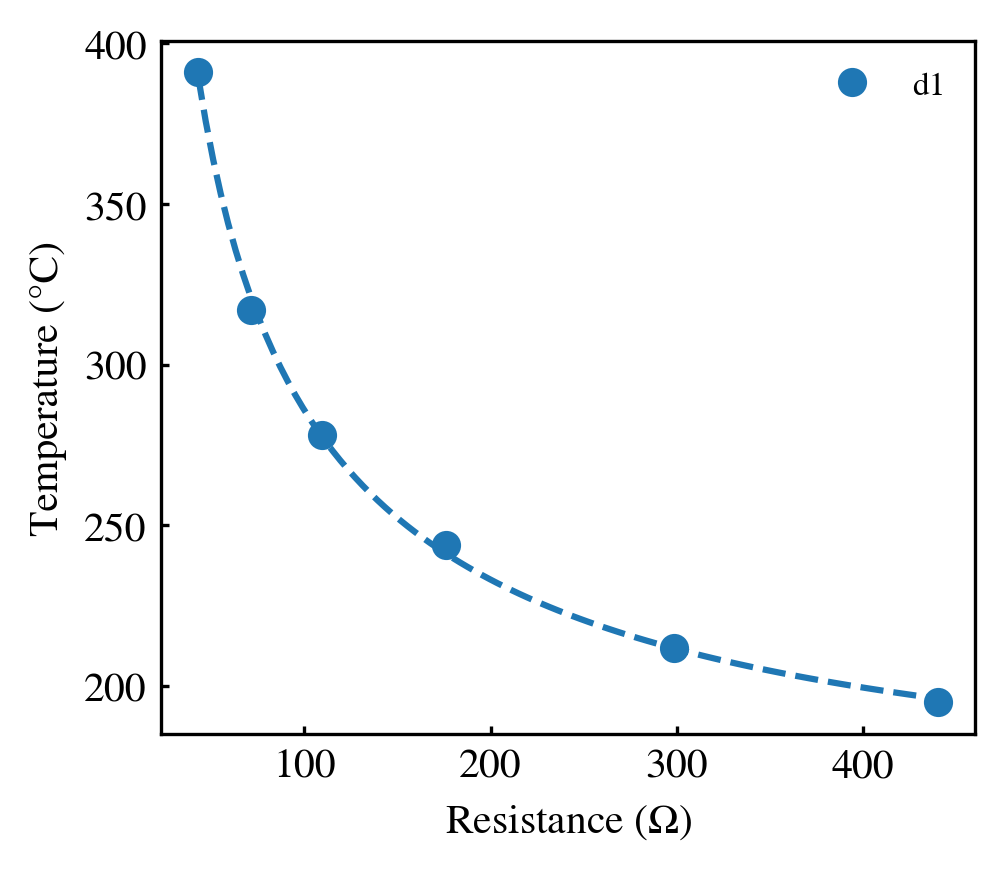

In [56]:
R = np.linspace(min(sh["R"]), max(sh["R"]), 100)
i = 0
typical_temp = np.array([210, 270, 320])
cmap = plt.get_cmap("tab10")
plt.figure(figsize=(3.5, 3), dpi=300)
for d in ["d1"]:
    plt.plot(sh["R"], sh[d], "o", label=d, color=cmap(i))
    popt, pcov = curve_fit(steinhart, sh["R"], sh[d], p0=[a, b, c])
    plt.plot(R, steinhart(R, *popt), ls="--", color=cmap(i))
    res_list = []
    for T in typical_temp:
        res = fsolve(func, args=(*popt, T), x0=100)
        res_list.append(res)
    print(f"{d}: {res_list}")
    i += 1
plt.xlabel("Resistance ($\\Omega$)")
plt.ylabel("Temperature (°C)")

plt.legend(frameon=False, fontsize=8)

## 3 Generate `adc_temperature` config

After the failure of using `thermistor`, we turn to use `adc_temperature`, a more flexible custom sensor module that allows any number of measured points to be fitted (by linear interpolation / extrapolation). This section visualizes the measured data points, and also provide a convenient tool which generates the `adc_temperature` config text automatically.

In [ ]:
# read the csv containing the measured data points (T, res)
df = pd.read_csv("~/Documents/protocal.csv").sort_values(by="T")
df_short = df.loc[df["T"]>200]

In [89]:
df

,T,res
0,20.0,100000.000
1,78.0,10984.000
4,199.0,449.049
3,220.0,297.793
2,241.0,212.328
5,266.0,151.345
6,287.0,110.422
7,313.0,82.779
8,340.5,62.954
9,359.0,55.011


Text(0, 0.5, 'Temperature (°C)')

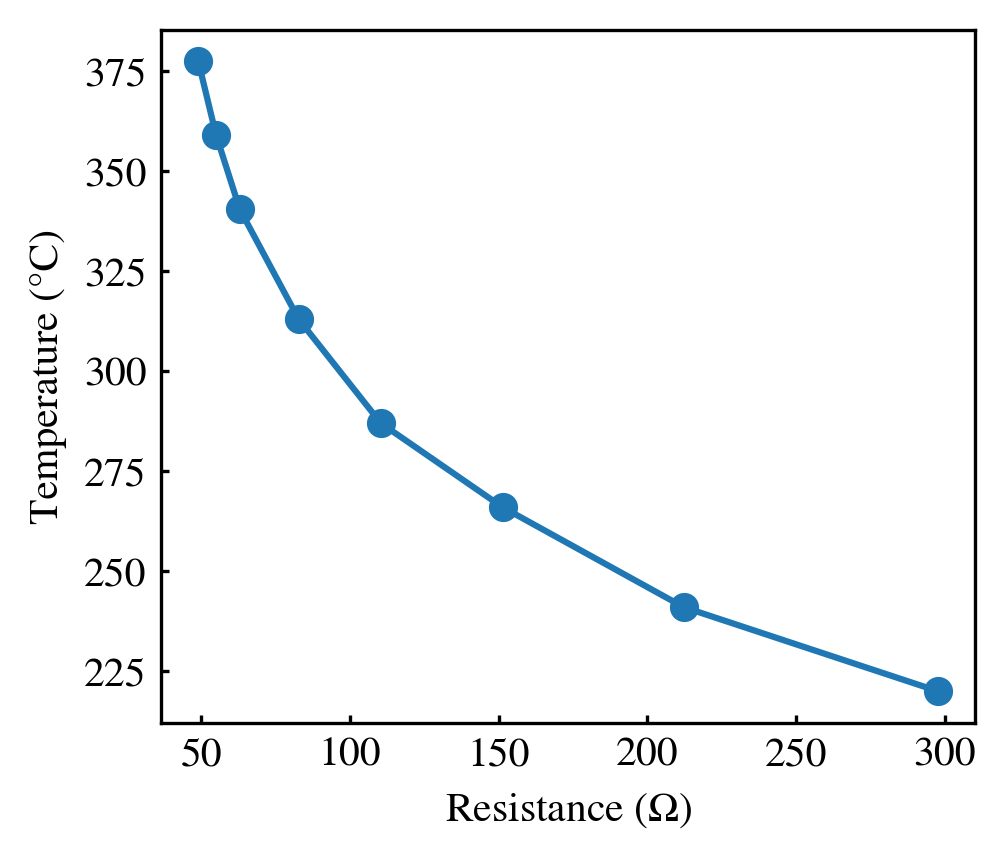

In [ ]:
# visualize
plt.figure(figsize=(3.5, 3), dpi=300)
plt.plot(df_short["res"], df_short["T"], "o", label="d3cal", ls="-")
plt.xlabel("Resistance ($\\Omega$)")
plt.ylabel("Temperature (°C)")

In [91]:
# generate config
tr_list = []
n = 1
for num, i in df.iterrows():
    tr_list.append(f"temperature{n}: {i['T']}\nresistance{n}: {i['res']}")
    n += 1
print("\n".join(tr_list))

temperature1: 20.0
resistance1: 100000.0
temperature2: 78.0
resistance2: 10984.0
temperature3: 199.0
resistance3: 449.049
temperature4: 220.0
resistance4: 297.793
temperature5: 241.0
resistance5: 212.328
temperature6: 266.0
resistance6: 151.345
temperature7: 287.0
resistance7: 110.422
temperature8: 313.0
resistance8: 82.779
temperature9: 340.5
resistance9: 62.954
temperature10: 359.0
resistance10: 55.011
temperature11: 377.5
resistance11: 48.998
